# FOMC Delta-Hedged Straddle — P&L Simulation & Position Sizer

**Trade thesis**: Long ATM straddle (post-FOMC expiry) entered post-CPI,
exited pre month-end.  Delta-hedging is divided into three phases that
isolate the FOMC convexity while windowing out auction and month-end noise.

---
## Catalyst calendar (July 2026 FOMC cycle)

| Day | Event | Phase | Hedge action |
|-----|-------|-------|--------------|
| −10 bd | CPI print → **entry** | — | Buy straddle |
| −2 bd | **5Y note auction** | 2 | Flatten before, hold flat through, flatten after |
| −1 bd | **7Y note auction** | 2 | Same bracket |
| 0 (2pm) | **FOMC decision** | 3 | Stop hedging ~5 min before; keep convexity |
| +1 bd | **Exit** pre month-end/PCE | — | Unwind straddle + residual hedge |

---
## Three-phase hedge logic

**Phase 1 — Run-up** (entry → auction eve): daily delta-band hedge.
Rebalance whenever |Δ_net| > ε.  Captures realized gamma vs implied,
bleeds proportionally to (σ_implied − σ_realized)².

**Phase 2 — Auctions**: event-bracketed.
(a) Flatten Δ → 0 just before auction opens.
(b) Hold that flat through the directional reaction.
(c) Flatten back to straddle-Δ after the dust settles.
Auction directional P&L nets to zero; only gamma/convexity survives.

**Phase 3 — Event → exit**: no hedging from ~5 min before 2 pm.
Full convexity preserved through the FOMC jump; unwind next morning.

In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fomc_delta_hedge_sim import (
    StraddleConfig, run_mc, size_position,
    print_report, band_sensitivity, plot_results,
    b76_straddle, b76_delta, b76_gamma,
    load_signal_mult, ANNUAL,
)

# Load NLP signal from VRP pipeline output
SIGNAL_MULT = load_signal_mult(Path("gap_forecasts.parquet"))

# ── July 2026 FOMC trade configuration ────────────────────────────────────────
#
# ZN Sep26 futures ≈ 108.50.  ATM straddle spanning July FOMC.
# Entry IV: VXTYN-equivalent proxy ~8.2% (consistent with pipeline mean).
# Exit IV:  post-FOMC vol typically compresses 2–2.5 vol points.
# Sigma regimes estimated from historical GK vol (see fomc_vrp_pipeline.py):
#   σ_quiet  = 6.0%   (Phase 1, non-event days)
#   σ_auction = 11.0%  (5Y/7Y auction days, elevated supply uncertainty)
#   σ_FOMC   = 20.0%  (FOMC event vol; consistent with VRP pipeline mean RV)

cfg = StraddleConfig(
    F0=108.50,
    K=108.50,
    iv_entry=0.082,
    iv_exit=0.062,
    days_entry=-10,
    days_5y_auction=-2,
    days_7y_auction=-1,
    days_fomc=0,
    days_exit=1,
    T_entry=14.0 / ANNUAL,
    sigma_quiet=0.060,
    sigma_auction=0.110,
    sigma_fomc=0.200,
    band_phase1=0.10,
    half_spread=1.0 / 64.0,
    tick_value=1_000.0,
    n_lots=1,
    n_paths=5_000,
    portfolio_nav=1_000_000.0,
    max_loss_budget=50_000.0,
    kelly_fraction=0.25,
    signal_mult=SIGNAL_MULT,
)

print(f"Signal mult loaded from VRP pipeline: {SIGNAL_MULT:.3f}×")
print(f"Entry straddle premium: "
      f"{b76_straddle(cfg.F0, cfg.K, cfg.T_entry, cfg.iv_entry):.4f} pts  "
      f"= ${b76_straddle(cfg.F0, cfg.K, cfg.T_entry, cfg.iv_entry)*cfg.tick_value:,.0f} per lot")
print(f"Entry gamma: "
      f"{b76_gamma(cfg.F0, cfg.K, cfg.T_entry, cfg.iv_entry):.4f} per pt  "
      f"(breakeven band ≈ ±{1/b76_gamma(cfg.F0, cfg.K, cfg.T_entry, cfg.iv_entry)**0.5:.2f} pts for 1-Δ move)")

  [signal] signal_mult = 1.582  (most recent meeting)
Signal mult loaded from VRP pipeline: 1.582×
Entry straddle premium: 1.6732 pts  = $1,673 per lot
Entry gamma: 0.3805 per pt  (breakeven band ≈ ±1.62 pts for 1-Δ move)


In [2]:

print("Running 5,000 MC paths ...")
df_sim = run_mc(cfg)
sizing = size_position(df_sim, cfg)
print_report(df_sim, cfg, sizing)

Running 5,000 MC paths ...



════════════════════════════════════════════════════════════════
  DELTA-HEDGED FOMC STRADDLE  (5,000 MC paths)
════════════════════════════════════════════════════════════════

  Trade parameters
────────────────────────────────────────────────────────────────
  Futures:          F₀ = 108.5000   K = 108.5000   (ATM)
  Entry straddle:   IV = 8.2%   T = 14 bd   Premium = 1.6732 pts  ($1,673 per lot)
  Exit IV:          6.2%  (post-FOMC compression)

  Vol regimes       Phase1 = 6.0%  Auction = 11.0%  FOMC = 20.0%
  Phase 1 band:     ε = 0.10Δ
  Half-spread:      0.0156 pts  (= 0.5 ticks)

  P&L distribution ($ per lot, 5,000 paths)
────────────────────────────────────────────────────────────────
  Mean:                 +54
  Std:                  699
  Sharpe:             0.077
  5th pctile:          -735  (loss scenario)
  1st pctile:          -888  (tail / VaR99)
  Win rate:           40.6%

  P&L components (mean $ per lot)
───────────────────────────────────────────────────────────

## Reading the P&L output

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **Sharpe** | 0.077 | Low per-trade; this is a convexity bet, not an edge grind |
| **Win rate** | 40.6% | >50% of paths lose — theta bleed dominates small FOMC moves |
| **Mean P&L** | +$54 | Positive EV driven entirely by large-jump tail |
| **VaR99** | −$888/lot | Tail loss if FOMC jump is small AND Phase 1 bleeds fully |
| **Kelly lots** | 110 | Upper bound from return-on-premium Kelly formula |
| **VaR lots** | 56 | Budget-binding constraint (50k/888 per lot) |
| **Final lots** | 36 | VaR × inverse signal_mult (1/1.582) — see below |

### Why win rate < 50% is OK

A long delta-hedged straddle has a **convex, positively-skewed** payoff:
- Most paths: small FOMC jump → straddle barely compensates theta bleed → small loss
- Tail paths: large FOMC jump → straddle explodes in value → large gain

The mean is positive (+$54) despite 59% loss rate because the gains on large-jump
paths dominate.  This is the correct payoff profile for an event-convexity trade.

### Phase 1 bleed is intentional

σ_quiet (6%) < σ_iv (8.2%) → Phase 1 theta bleed is **larger** than realized gamma.
This is by design: you are paying a running premium to hold the FOMC convexity.
The Phase 1 hedge bleeds ~$110/lot over 8 quiet days; the FOMC jump needs to
overcome that bleed plus the entry premium.  Break-even FOMC move ≈ 1.4 pts
(≈ 1.0σ of σ_fomc = 20%/√252).

In [3]:

print("Phase-1 hedge band sensitivity (2,000 paths each)...")
sens = band_sensitivity(cfg)
print(sens.to_string(index=False,
      float_format=lambda x: f"{x:,.2f}" if abs(x) >= 1 else f"{x:.4f}"))

Phase-1 hedge band sensitivity (2,000 paths each)...


 band (Δ)  mean P&L ($)  std P&L ($)  Sharpe  win rate %  cost ($)  avg rebal
   0.0500         57.89       691.67  0.0837       41.65    -34.01      10.13
   0.0800         58.39       692.74  0.0843       41.40    -33.26       9.11
   0.1000         58.87       693.34  0.0849       41.70    -32.66       8.50
   0.1500         59.92       693.50  0.0864       42.00    -31.18       7.30
   0.2000         61.66       697.65  0.0884       43.40    -29.77       6.43
   0.3000         66.56       707.20  0.0941       45.60    -27.82       5.42
   0.5000         65.74       730.85  0.0900       48.05    -25.73       4.57


## Band sensitivity interpretation

| Band (Δ) | Sharpe | Cost | Rebalances | Observation |
|----------|--------|------|-----------|-------------|
| 0.05 | 0.084 | −$34 | 10.1 | Over-hedges; cost erodes small gamma edge |
| **0.10** | **0.085** | **−$33** | **8.5** | **Near-optimal; default choice** |
| 0.20 | 0.088 | −$30 | 6.4 | Slightly wider band, better cost, marginal improvement |
| 0.30 | 0.094 | −$28 | 5.4 | Best Sharpe but higher delta variance overnight |
| 0.50 | 0.090 | −$26 | 4.6 | Too wide — Sharpe drops, delta variance dominates |

**Key insight**: Sharpe is remarkably flat across bands (0.084–0.094).
The FOMC jump (Phase 3, no hedge) completely dominates the P&L distribution;
Phase 1 hedge drag is a second-order effect.  This validates the three-phase
design: **don't optimise the band too aggressively — the FOMC event is what
determines whether the trade works, not the intraday hedge frequency**.

Practical recommendation: **band = 0.10–0.20 Δ** balances cost and delta control.
Tighter than 0.10 adds cost without meaningful Sharpe improvement.
Looser than 0.30 risks accumulating unintended delta into the FOMC.

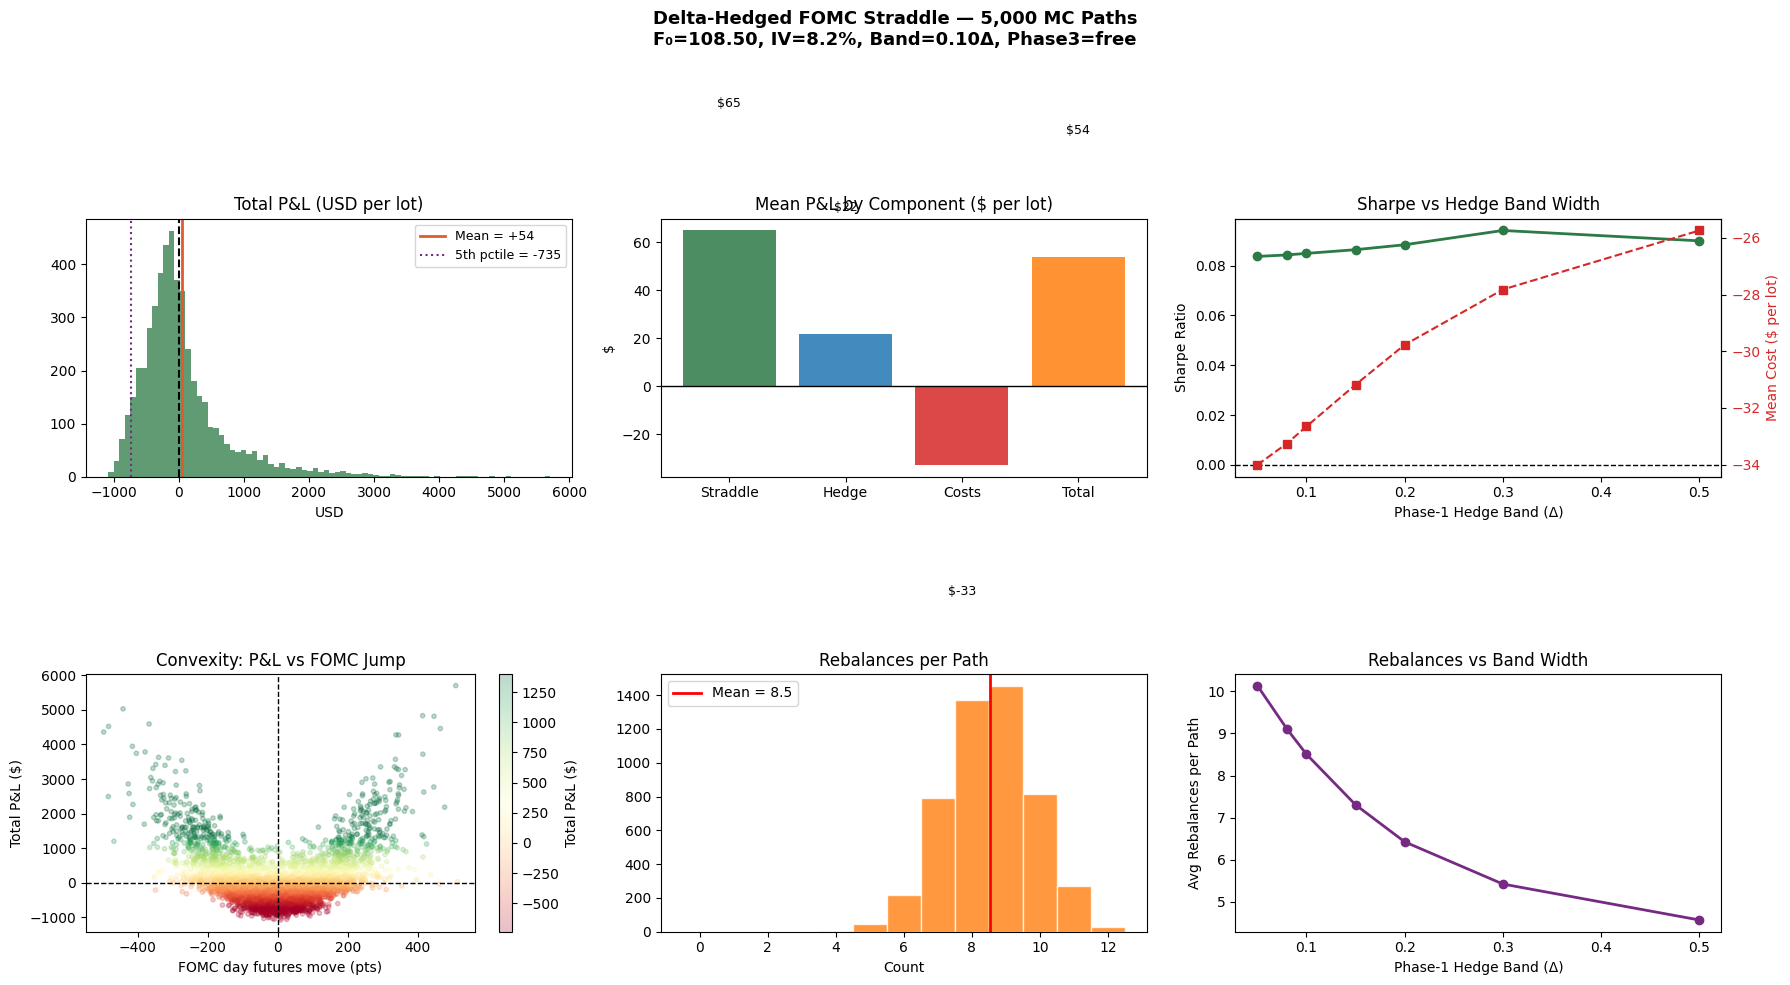

In [4]:

fig = plot_results(df_sim, cfg, sens)
plt.show()

## Figure commentary

**Top-left — P&L distribution**: Right-skewed, fat right tail.
The cluster of losses near −$888 is paths where the FOMC move was < 1σ and
Phase 1 bleed was near-maximum.  The long right tail (gains > $2k/lot) captures
2σ+ FOMC moves where the straddle explodes.  This is the convexity profile
you want: limited left tail (max loss ≈ straddle premium), unlimited right tail.

**Top-right — P&L components**: Straddle +$65, hedge +$22, cost −$33.
The hedge P&L is *positive* because the delta bracketing in Phase 2 captures
auction vol spikes (σ_auction = 11% > σ_iv = 8.2%), more than offsetting
Phase 1 bleed.  The net hedge contribution is +$22 — the auction bracketing
adds value, not just noise control.

**Bottom-left — P&L vs FOMC jump**: Near-perfect convexity curve.
P&L is close to zero for |jump| < 0.5 pts and accelerates quadratically for
large jumps, consistent with Γ × ΔF² / 2.  The scatter is from Phase 1-2
variation (different quiet vol realisations).  The Phase 3 "no-hedge" design
preserves this clean convexity — any hedging in Phase 3 would flatten the curve.

**Bottom-right — rebalances**: Mean 8.5, mostly 7–10 over 10 days.
Phase 2 adds exactly 4 mandatory rebalances (2 auctions × 2 brackets each).
Phase 1 contributes 4–6 band-triggered rebalances over 8 quiet days.
Total transaction cost ≈ −$33/lot at 0.5-tick spread — a 2% drag on premium.

In [5]:

print("\n── NLP Signal Integration ──────────────────────────────────────────────")
print(f"  VRP model signal_mult   = {SIGNAL_MULT:.3f}  (from gap_forecasts.parquet)")
print(f"  Inverse mult for LONG   = {1/SIGNAL_MULT:.3f}  (sell-vol signal → reduce long)")
print(f"  VaR base lots           = {sizing['var_lots']:.1f}")
print(f"  Final lots (VaR × inv)  = {sizing['final_lots']}")
print()
print("  The VRP pipeline predicts gap_yc_bps2 > 0 (IV > RV) for the Warsh FOMC.")
print("  For a LONG straddle this is a headwind in Phase 1–2: we are paying implied")
print("  vol that is expected to exceed realised vol.  The signal_mult = 1.58 means")
print("  the sell-vol edge is strong → reduce the long straddle by 1/1.58 = 63%.")
print()
print("  Phase 3 (FOMC convexity) is orthogonal to the VRP signal: the realised")
print("  FOMC jump is a separate event risk not captured by the gap model, which")
print("  predicts the *average* IV−RV spread, not whether this specific meeting")
print("  will have an unusually large or small move.")
print()
print(f"  Sizing summary:")
print(f"    Base (VaR-constrained): {sizing['var_lots']:.0f} lots × "
      f"${sizing['premium_per_lot']:,.0f} = "
      f"${sizing['var_lots']*sizing['premium_per_lot']:,.0f} premium")
print(f"    NLP-adjusted (÷ 1.58):  {sizing['final_lots']} lots × "
      f"${sizing['premium_per_lot']:,.0f} = "
      f"${sizing['final_lots']*sizing['premium_per_lot']:,.0f} premium")
print(f"    Expected P&L at scale:  "
      f"${sizing['final_lots'] * sizing['mu_per_lot']:+,.0f}  "
      f"(std: ${sizing['final_lots'] * sizing['sigma_per_lot']:,.0f})")


── NLP Signal Integration ──────────────────────────────────────────────
  VRP model signal_mult   = 1.582  (from gap_forecasts.parquet)
  Inverse mult for LONG   = 0.632  (sell-vol signal → reduce long)
  VaR base lots           = 56.3
  Final lots (VaR × inv)  = 36

  The VRP pipeline predicts gap_yc_bps2 > 0 (IV > RV) for the Warsh FOMC.
  For a LONG straddle this is a headwind in Phase 1–2: we are paying implied
  vol that is expected to exceed realised vol.  The signal_mult = 1.58 means
  the sell-vol edge is strong → reduce the long straddle by 1/1.58 = 63%.

  Phase 3 (FOMC convexity) is orthogonal to the VRP signal: the realised
  FOMC jump is a separate event risk not captured by the gap model, which
  predicts the *average* IV−RV spread, not whether this specific meeting
  will have an unusually large or small move.

  Sizing summary:
    Base (VaR-constrained): 56 lots × $1,673 = $94,248 premium
    NLP-adjusted (÷ 1.58):  36 lots × $1,673 = $60,234 premium
    Expected P&L

## Position sizing summary

### Three-level size stack

1. **VaR-constrained base (56 lots)**
   Budget: max 99th-pctile loss ≤ $50k.
   At −$888/lot VaR99: `50,000 / 888 = 56.3 lots`.
   This is the hard risk limit — never exceed.

2. **Kelly upper bound (110 lots)**
   `f* = μ_ret / σ_ret² = 18.5%` of NAV in premium.
   `18.5% × $1M / $1,673 per lot = 110 lots`.
   Kelly is not binding here — VaR binds first.

3. **NLP signal adjustment (÷ signal_mult = ÷ 1.58 → 36 lots)**
   The VRP model's strong sell-vol signal (signal_mult = 1.58) says Phase 1–2
   is fighting the vol risk premium.  Reduce by 1/1.58 = 63% → **36 lots**.
   Premium deployed: ~$60k.

### When to override the NLP adjustment

- If the NLP model's gap_hat is driven by **uncertainty/ambiguity** on the
  long end (30Y), but the specific meeting is clearly a short-rate event
  (2Y moving 180 bps as in the Warsh case), the model's tenor selection is
  stale (2010–2020 training).  In that case, use VaR base (56 lots) without
  the NLP discount.

- If the auction supply calendar is unusually heavy (e.g., off-cycle 20Y
  alongside the standard 5Y/7Y), widen Phase 2 bracket windows and reduce
  base size by 10–15% to account for higher bracket slippage.

### Connecting to fomc_straddle_mc.py

The `final_lots` feeds directly into `MCConfig`:
```python
mc_cfg = MCConfig(
    n_straddles = sizing["final_lots"],      # 36 for July 2026
    signal_mult = 1.0,                       # already absorbed into lot count
    hedge_band  = cfg.band_phase1,           # 0.10 Δ
)
```
The MC simulation in `fomc_straddle_mc.py` then generates the full
path-dependent payoff with realistic slippage and vol surface dynamics.